# 04b Theme 2: Social Commerce Signals

Core question: what is being sold × how it is presented × how strongly it is sold × how audiences respond.

Structure:
1. Commerce Intensity (transparent 0–3+ score)
2. Parallel cross-tabs (content + product dimensions)
3. Nike vs Adidas commerce orientation
4. Commerce Intensity × engagement trend
5. Commerce–Engagement matrix (group bubbles)

Observational only. Not causal.

In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd()
if not (ROOT / "configs").exists() and (ROOT.parent / "configs").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))

from IPython.display import display

from tiktok_brand.analysis.data import CLUSTER_COL, load_feature_table, project_paths
from tiktok_brand.analysis.commerce import (
    CONTENT_DIMS,
    PRODUCT_DIMS,
    add_commerce_intensity,
    brand_commerce_mix,
    brand_commerce_summary,
    brand_driver_commerce,
    commerce_by_dimension,
    commerce_engagement_bubbles,
    commerce_engagement_trend,
)
from tiktok_brand.analysis.plots import (
    brand_commerce_stacked,
    commerce_bri_bubbles,
    commerce_engagement_line,
    commerce_intensity_hbar,
)
from tiktok_brand.analysis.present import format_cluster_label, humanize_label

import os
os.chdir(ROOT)
PATHS = project_paths(ROOT / "configs" / "project.yaml")
df = load_feature_table(PATHS["feature_table"])
df["content_cluster"] = df[CLUSTER_COL].map(format_cluster_label)
df = add_commerce_intensity(df)

print(
    f"rows={len(df):,}  "
    f"mean_score={df['commerce_intensity_score'].mean():.2f}  "
    f"has_giveaway_rate={df['has_giveaway'].mean():.1%}"
)


rows=4,457  mean_score=0.04  has_giveaway_rate=0.1%


## 1. Commerce Intensity

Single transparent score from four existing caption cues:

`Purchase CTA + Discovery CTA + Promo Language + Giveaway`

| Score | Bin |
|------:|:----|
| 0 | None |
| 1 | Low |
| 2 | Medium |
| 3+ | High |

No separate "Direct Commerce" construct. Everything below hangs off this axis.

In [2]:
comp = df[["has_purchase_cta", "has_discovery_traffic_cta", "has_promo_language", "has_giveaway"]].mean()
comp.index = ["purchase_cta", "discovery_cta", "promo_language", "giveaway"]
display(comp.rename("rate").to_frame().style.format("{:.1%}"))

mix = (
    df["commerce_intensity"]
    .astype(str)
    .value_counts()
    .reindex(["None", "Low", "Medium", "High"])
    .to_frame("n")
)
mix["share"] = mix["n"] / mix["n"].sum()
display(mix.style.format({"share": "{:.1%}"}))

Matplotlib is building the font cache; this may take a moment.


,rate
purchase_cta,0.8%
discovery_cta,0.9%
promo_language,1.8%
giveaway,0.1%


,n,share
commerce_intensity,,
None,4299.000000,96.5%
Low,154.000000,3.5%
Medium,4.000000,0.1%
High,nan,nan%


## 2. Commerce by content / product dimension

Videos carry multiple annotations at once. Parallel cross-tabs answer the same question for each axis:

Which content types, semantic clusters, brand styles, visual presentations, and product taxonomies more often carry stronger commerce cues?

Product line / category especially matter for: *is commerce pressure concentrated on certain products?*


=== Content type (n levels=7) ===


,level,n,mean_commerce_intensity,high_commerce_share,purchase_cta_rate,promo_language_rate
0,Product Promo,123,0.47,0.0%,9.8%,23.6%
1,Collaboration,146,0.07,0.0%,1.4%,4.1%
2,Product Showcase,162,0.05,0.0%,1.9%,1.9%
3,Product Review,109,0.05,0.0%,1.8%,1.8%
4,Vibe OOTD,301,0.03,0.0%,1.7%,1.3%
5,Tutorial Utility,85,0.01,0.0%,0.0%,1.2%
6,Official Campaign,38,0.00,0.0%,0.0%,0.0%


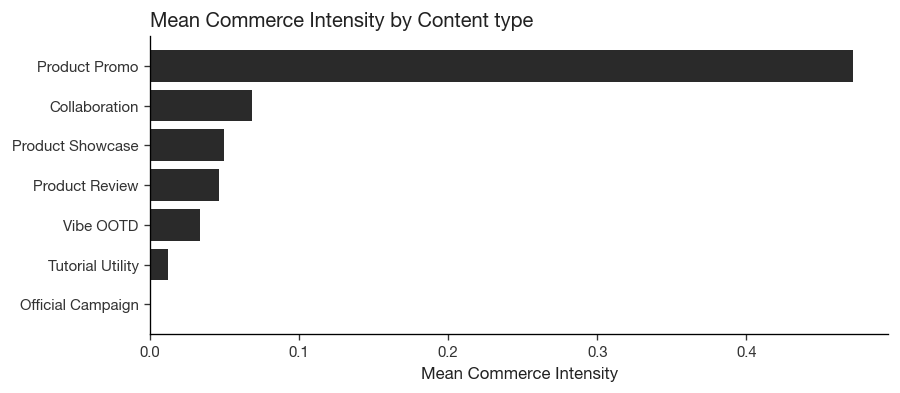


=== Text / content cluster (n levels=13) ===


,level,n,mean_commerce_intensity,high_commerce_share,purchase_cta_rate,promo_language_rate
0,"1 — Jordan Brand Culture, Releases & Community",156,0.13,0.0%,1.3%,8.3%
1,"3 — Interactive Brand, Creator & Pop-Culture Content",450,0.07,0.0%,1.8%,2.9%
2,10 — Nike Air Product Lines & Commerce,210,0.04,0.0%,0.0%,2.9%
3,2 — Sneaker Shopping & Product Discovery,557,0.04,0.0%,1.3%,2.3%
4,"0 — Ootd, Outfit Inspiration & Streetwear",568,0.04,0.0%,1.2%,1.9%
5,"7 — Sneakerhead Reviews, Styling & Enthusiast Culture",399,0.04,0.0%,1.0%,1.5%
6,"6 — Running Shoes, Training & Marathon Culture",354,0.03,0.0%,0.6%,1.4%
7,5 — Elite Athlete Stories & Sporting Moments,414,0.03,0.0%,0.2%,1.4%
8,4 — Basketball Athletes & Signature Footwear,220,0.02,0.0%,0.5%,0.5%
9,9 — Football Athletes & Adidas Football Culture,428,0.01,0.0%,0.2%,1.2%


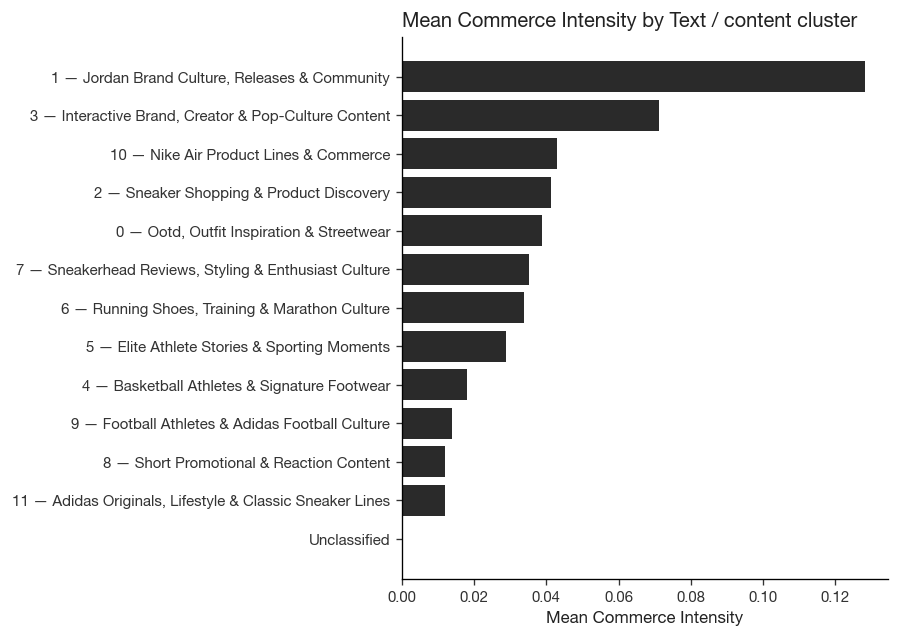


=== Brand style (n levels=4) ===


,level,n,mean_commerce_intensity,high_commerce_share,purchase_cta_rate,promo_language_rate
0,Retro,93,0.11,0.0%,2.2%,7.5%
1,Performance,370,0.05,0.0%,0.8%,3.5%
2,Lifestyle,525,0.03,0.0%,1.3%,1.5%
3,Technical,130,0.03,0.0%,1.5%,1.5%


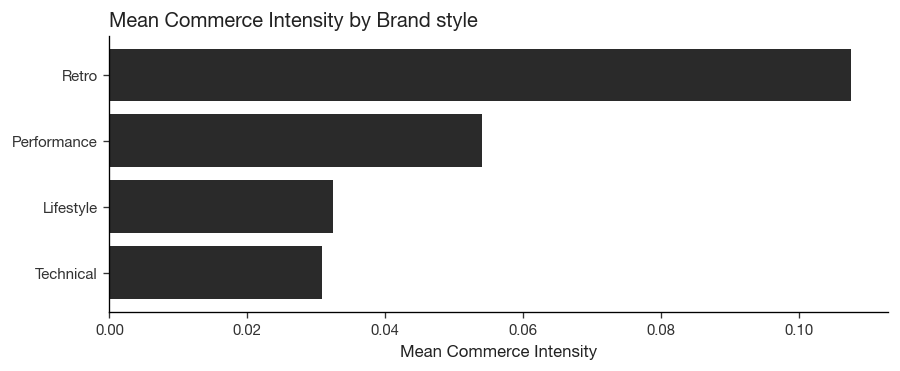


=== Visual format (n levels=7) ===


,level,n,mean_commerce_intensity,high_commerce_share,purchase_cta_rate,promo_language_rate
0,Archival Retro,49,0.08,0.0%,2.0%,4.1%
1,Other,89,0.08,0.0%,0.0%,6.7%
2,Talking Head,449,0.04,0.0%,0.7%,2.4%
3,Product Closeup,1381,0.04,0.0%,0.7%,1.9%
4,Unclassified,693,0.03,0.0%,1.0%,2.2%
5,Sports Action,567,0.03,0.0%,0.5%,1.6%
6,On Body Styling,1215,0.03,0.0%,0.8%,1.0%


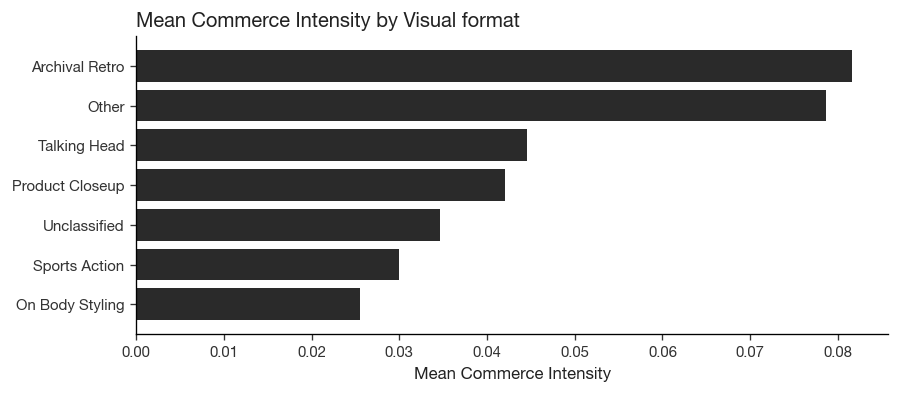


=== Visual setting (n levels=9) ===


,level,n,mean_commerce_intensity,high_commerce_share,purchase_cta_rate,promo_language_rate
0,Gym Training,313,0.05,0.0%,0.6%,3.2%
1,Event Crowd,277,0.05,0.0%,1.1%,2.2%
2,Other,152,0.04,0.0%,0.7%,2.0%
3,Outdoor,785,0.04,0.0%,0.6%,2.2%
4,Retail Store,1273,0.04,0.0%,0.9%,1.7%
5,Unclassified,693,0.03,0.0%,1.0%,2.2%
6,Sports Venue,383,0.03,0.0%,0.5%,0.3%
7,Studio,525,0.03,0.0%,0.6%,1.5%
8,Home Indoor,56,0.00,0.0%,0.0%,0.0%


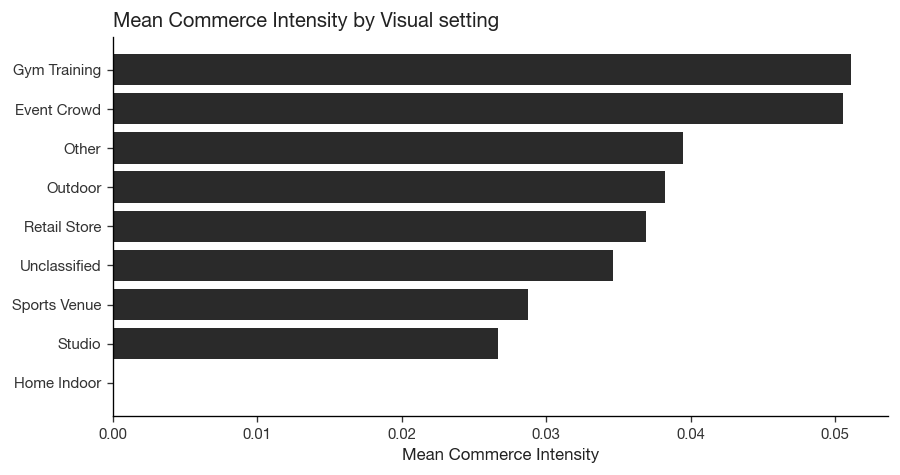


=== Product category (n levels=4) ===


,level,n,mean_commerce_intensity,high_commerce_share,purchase_cta_rate,promo_language_rate
0,Accessories,333,0.05,0.0%,0.9%,2.4%
1,Shoes,2013,0.04,0.0%,0.6%,2.3%
2,Apparel,431,0.04,0.0%,1.9%,0.9%
3,Uncategorized,1819,0.03,0.0%,0.7%,1.5%


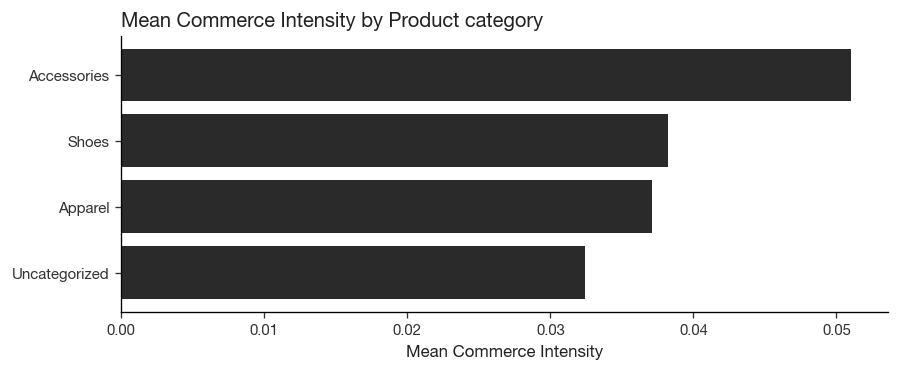


=== Product line (n levels=16) ===


,level,n,mean_commerce_intensity,high_commerce_share,purchase_cta_rate,promo_language_rate
0,Jordan,158,0.11,0.0%,1.3%,6.3%
1,Tracksuit,62,0.08,0.0%,3.2%,3.2%
2,Air Max,96,0.06,0.0%,1.0%,5.2%
3,Superstar,24,0.04,0.0%,4.2%,0.0%
4,Af1,73,0.04,0.0%,0.0%,2.7%
5,Samba,222,0.03,0.0%,2.3%,0.5%
6,Gazelle,111,0.02,0.0%,0.0%,0.9%
7,Originals Apparel,114,0.02,0.0%,0.9%,0.0%
8,Spezial,121,0.02,0.0%,0.8%,0.8%
9,Tech Fleece,94,0.01,0.0%,1.1%,0.0%


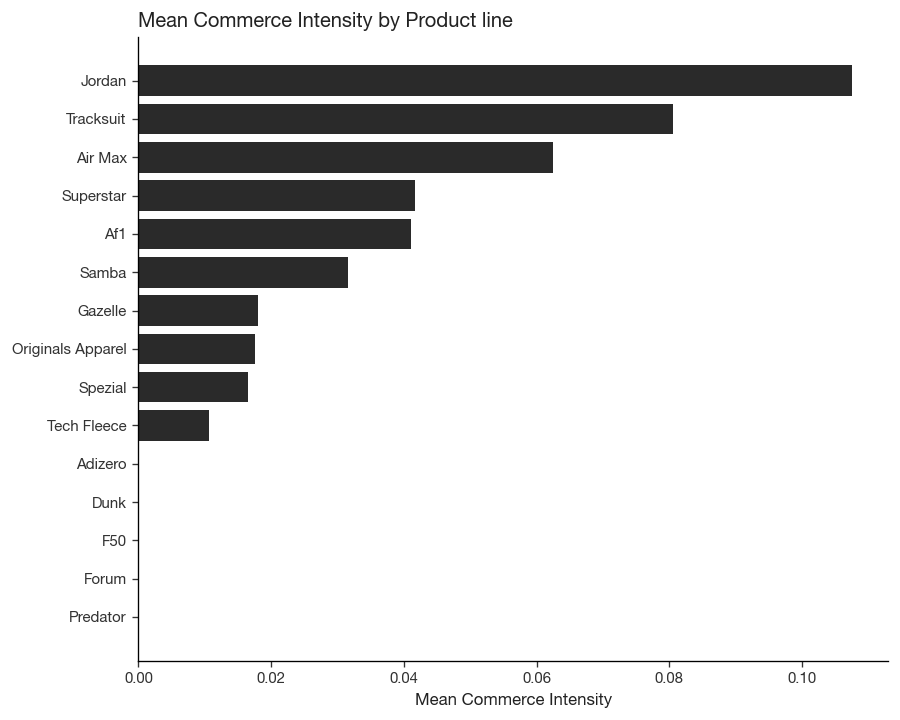

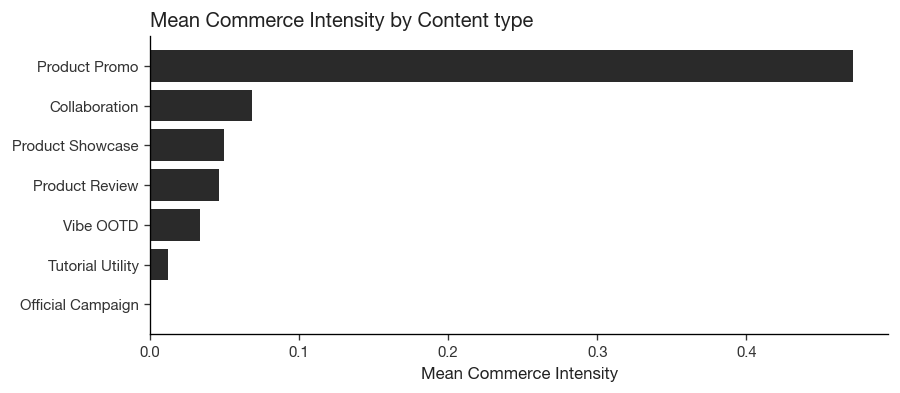

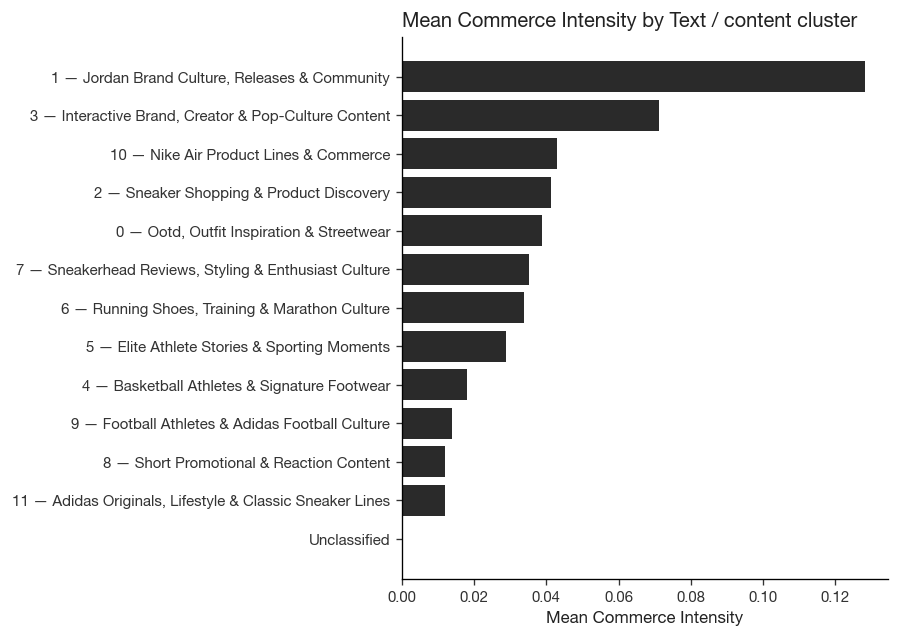

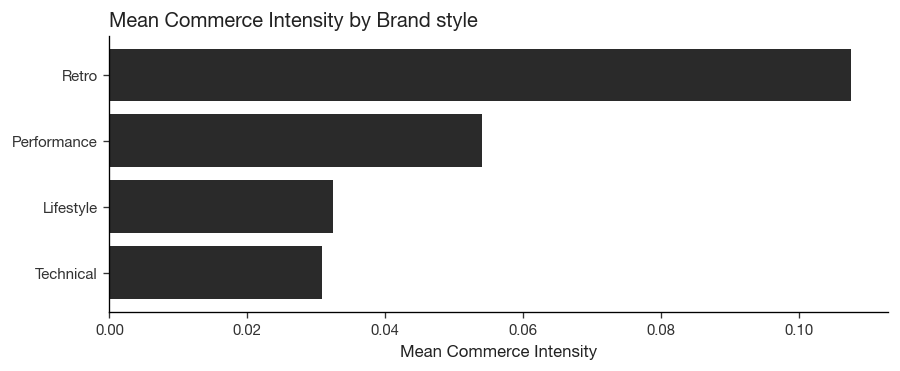

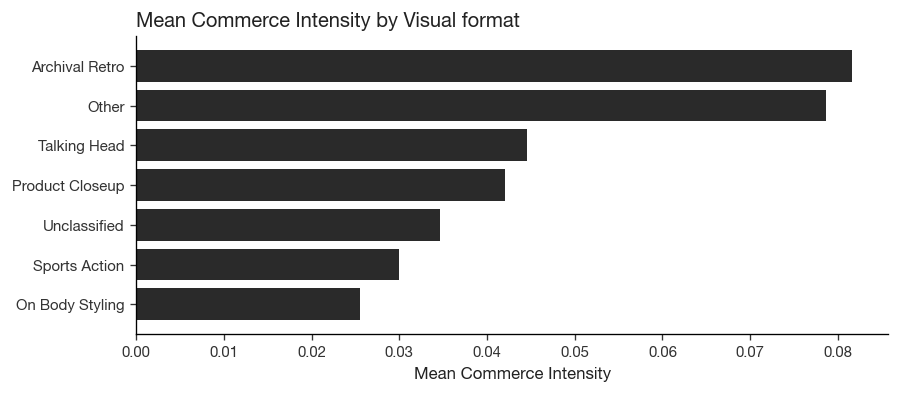

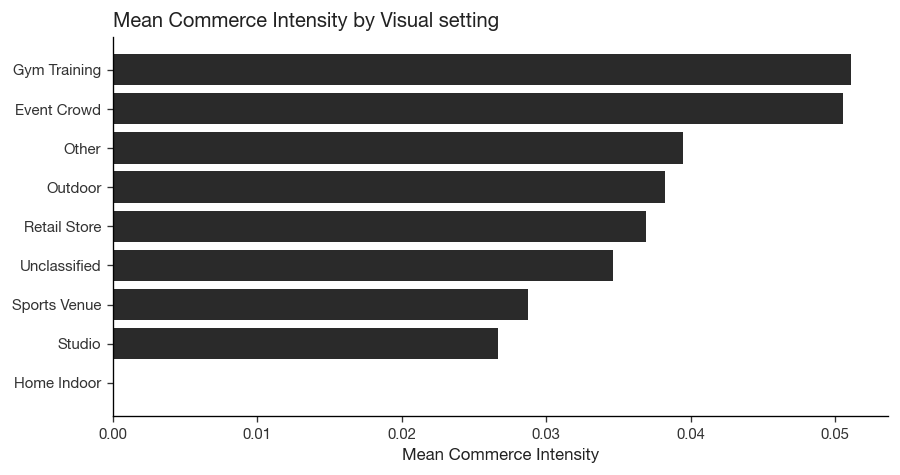

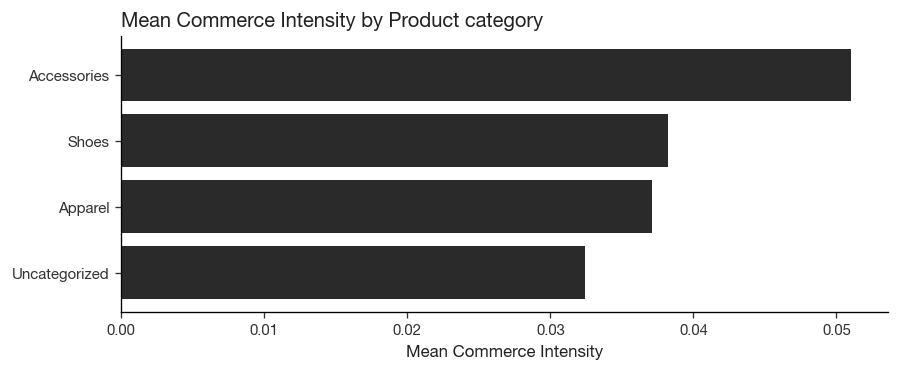

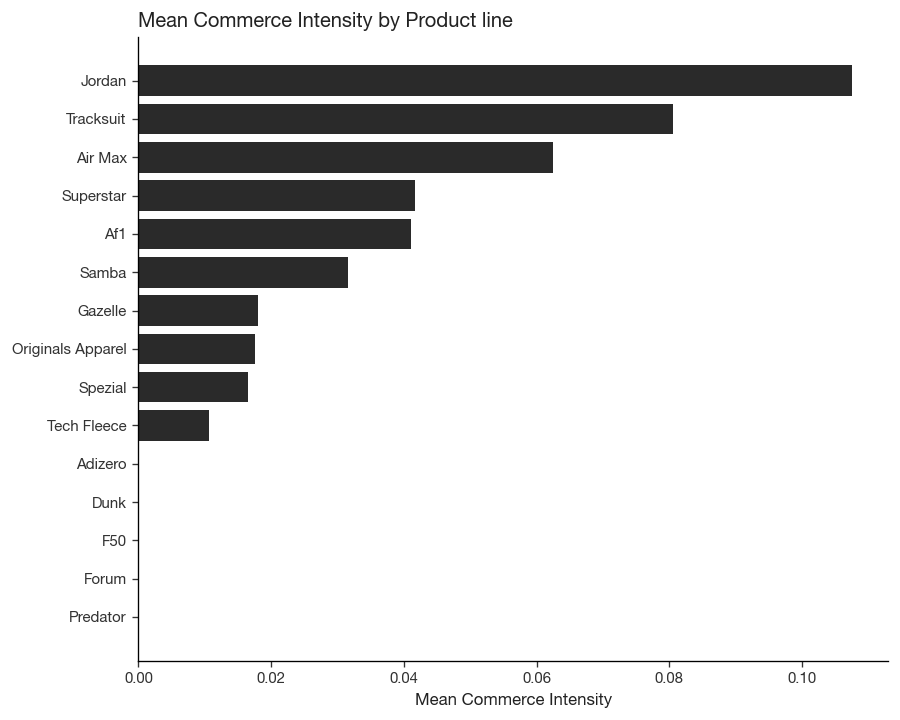

In [3]:
DIM_LABELS = {
    "content_type": "Content type",
    "content_cluster": "Text / content cluster",
    "brand_styles": "Brand style",
    "visual_format": "Visual format",
    "visual_setting": "Visual setting",
    "product_categories": "Product category",
    "product_lines": "Product line",
}

tabs = {}
for dim in list(CONTENT_DIMS) + list(PRODUCT_DIMS):
    if dim not in df.columns:
        print(f"skip missing: {dim}")
        continue
    tab = commerce_by_dimension(df, dim, min_count=15)
    tabs[dim] = tab
    title = DIM_LABELS.get(dim, dim)
    print(f"\n=== {title} (n levels={len(tab)}) ===")
    show = tab[
        [
            "level",
            "n",
            "mean_commerce_intensity",
            "high_commerce_share",
            "purchase_cta_rate",
            "promo_language_rate",
        ]
    ].copy()
    show["level"] = show["level"].map(humanize_label)
    display(
        show.style.format(
            {
                "mean_commerce_intensity": "{:.2f}",
                "high_commerce_share": "{:.1%}",
                "purchase_cta_rate": "{:.1%}",
                "promo_language_rate": "{:.1%}",
            }
        )
    )
    display(commerce_intensity_hbar(tab, title=f"Mean Commerce Intensity by {title}"))

## 3. Nike vs Adidas: who is more commerce-oriented?

Brand-level distribution first (stacked shares + component rates). Then drill into which content / product levels drive any gap.

,brand,n,mean_commerce_intensity,high_commerce_share,purchase_cta_rate,discovery_traffic_cta_rate,promo_language_rate,giveaway_rate,share_none,share_low,share_medium,share_high
0,nike,2317,0.05,0.0%,0.9%,1.4%,2.6%,0.1%,95.1%,4.7%,0.1%,0.0%
1,adidas,2140,0.02,0.0%,0.7%,0.4%,1.0%,0.1%,97.9%,2.1%,0.0%,0.0%


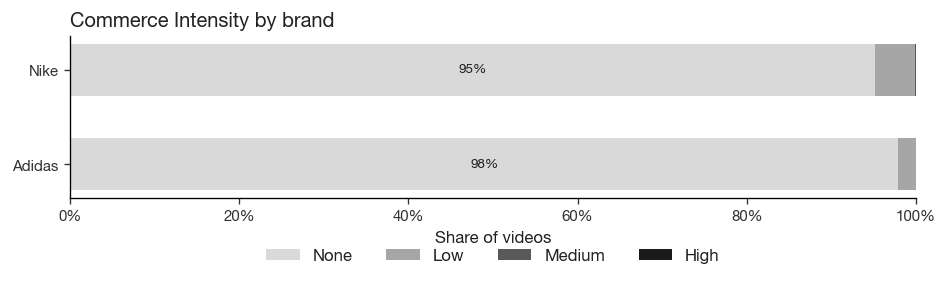

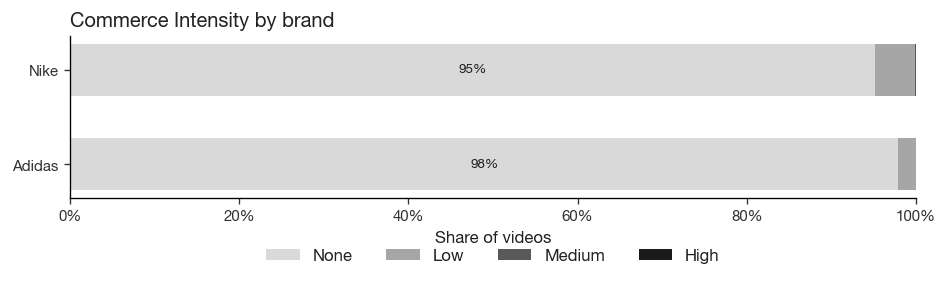

In [4]:
summary = brand_commerce_summary(df)
display(
    summary.style.format(
        {
            "mean_commerce_intensity": "{:.2f}",
            "high_commerce_share": "{:.1%}",
            "purchase_cta_rate": "{:.1%}",
            "discovery_traffic_cta_rate": "{:.1%}",
            "promo_language_rate": "{:.1%}",
            "giveaway_rate": "{:.1%}",
            "share_none": "{:.1%}",
            "share_low": "{:.1%}",
            "share_medium": "{:.1%}",
            "share_high": "{:.1%}",
        }
    )
)

mix_brand = brand_commerce_mix(df)
display(brand_commerce_stacked(mix_brand))

In [5]:
# What drives the brand gap?
for dim in ["content_type", "product_categories", "product_lines", "content_cluster"]:
    if dim not in df.columns:
        continue
    drv = brand_driver_commerce(df, dim, min_count=12)
    print(f"\n=== Brand × {DIM_LABELS.get(dim, dim)} (top by mean intensity) ===")
    show = drv.sort_values("mean_commerce_intensity", ascending=False).head(16)[
        ["brand", "level", "n", "mean_commerce_intensity", "high_commerce_share", "purchase_cta_rate"]
    ].copy()
    show["level"] = show["level"].map(humanize_label)
    display(
        show.style.format(
            {
                "mean_commerce_intensity": "{:.2f}",
                "high_commerce_share": "{:.1%}",
                "purchase_cta_rate": "{:.1%}",
            }
        )
    )


=== Brand × Content type (top by mean intensity) ===


,brand,level,n,mean_commerce_intensity,high_commerce_share,purchase_cta_rate
0,nike,Product Promo,88,0.50,0.0%,8.0%
7,adidas,Product Promo,35,0.40,0.0%,14.3%
1,nike,Product Showcase,55,0.11,0.0%,3.6%
2,nike,Collaboration,69,0.10,0.0%,0.0%
3,nike,Product Review,50,0.06,0.0%,2.0%
8,adidas,Collaboration,77,0.04,0.0%,2.6%
4,nike,Vibe OOTD,113,0.04,0.0%,1.8%
9,adidas,Product Review,59,0.03,0.0%,1.7%
10,adidas,Vibe OOTD,188,0.03,0.0%,1.6%
5,nike,Tutorial Utility,40,0.03,0.0%,0.0%



=== Brand × Product category (top by mean intensity) ===


,brand,level,n,mean_commerce_intensity,high_commerce_share,purchase_cta_rate
0,nike,Accessories,226,0.06,0.0%,0.9%
1,nike,Shoes,975,0.05,0.0%,0.6%
2,nike,Uncategorized,1009,0.05,0.0%,0.9%
4,adidas,Apparel,266,0.04,0.0%,1.5%
3,nike,Apparel,165,0.04,0.0%,2.4%
5,adidas,Accessories,107,0.03,0.0%,0.9%
6,adidas,Shoes,1038,0.02,0.0%,0.7%
7,adidas,Uncategorized,810,0.01,0.0%,0.4%



=== Brand × Product line (top by mean intensity) ===


,brand,level,n,mean_commerce_intensity,high_commerce_share,purchase_cta_rate
0,nike,Jordan,158,0.11,0.0%,1.3%
6,adidas,Tracksuit,49,0.10,0.0%,4.1%
1,nike,Air Max,96,0.06,0.0%,1.0%
7,adidas,Superstar,24,0.04,0.0%,4.2%
2,nike,Af1,73,0.04,0.0%,0.0%
8,adidas,Samba,222,0.03,0.0%,2.3%
9,adidas,Gazelle,111,0.02,0.0%,0.0%
10,adidas,Originals Apparel,114,0.02,0.0%,0.9%
11,adidas,Spezial,121,0.02,0.0%,0.8%
3,nike,Tech Fleece,92,0.01,0.0%,1.1%



=== Brand × Text / content cluster (top by mean intensity) ===


,brand,level,n,mean_commerce_intensity,high_commerce_share,purchase_cta_rate
0,nike,"1 — Jordan Brand Culture, Releases & Community",153,0.13,0.0%,1.3%
1,nike,"3 — Interactive Brand, Creator & Pop-Culture Content",289,0.10,0.0%,2.4%
2,nike,"6 — Running Shoes, Training & Marathon Culture",172,0.06,0.0%,0.6%
3,nike,2 — Sneaker Shopping & Product Discovery,266,0.05,0.0%,1.1%
4,nike,10 — Nike Air Product Lines & Commerce,201,0.04,0.0%,0.0%
5,nike,"0 — Ootd, Outfit Inspiration & Streetwear",245,0.04,0.0%,1.2%
6,nike,"7 — Sneakerhead Reviews, Styling & Enthusiast Culture",200,0.04,0.0%,1.0%
12,adidas,"0 — Ootd, Outfit Inspiration & Streetwear",323,0.04,0.0%,1.2%
13,adidas,2 — Sneaker Shopping & Product Discovery,291,0.03,0.0%,1.4%
7,nike,5 — Elite Athlete Stories & Sporting Moments,326,0.03,0.0%,0.3%


## 4. Does stronger commerce sacrifice engagement?

Do not assume a penalty. Report the shape:

- A: monotone down (commerce ↑, engagement ↓)
- B: inverted U (light framing ok; heavy pressure weaker)
- C: flat / unclear

Primary Y is BRI (brand-relative). WER and Top-10% rate (sample WER ≥ Q90) sit beside it.

Top-10% = WER >= sample Q90 (0.01729)


,commerce_intensity,n,median_bri,median_wer,top10_rate
0,None,4299,1.005,0.0064,10.0%
1,Low,154,0.952,0.0058,11.7%
2,Medium,4,0.870,0.0051,0.0%
3,High,0,nan,nan,nan%


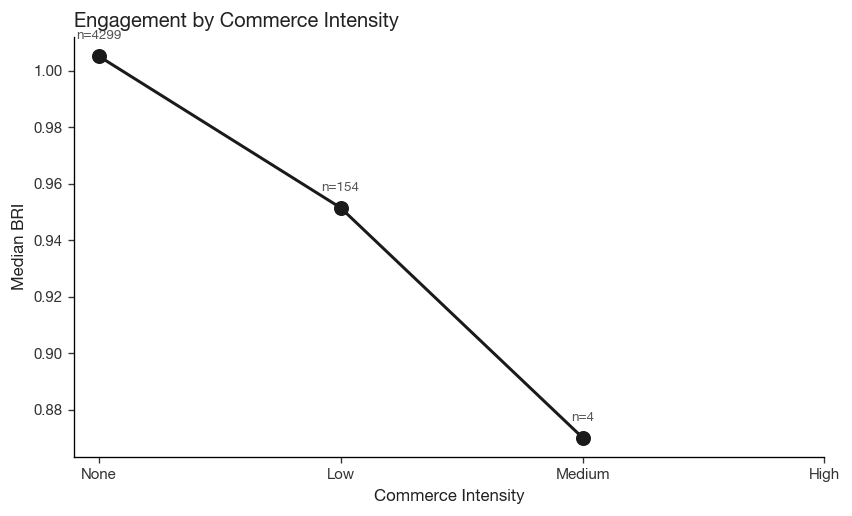

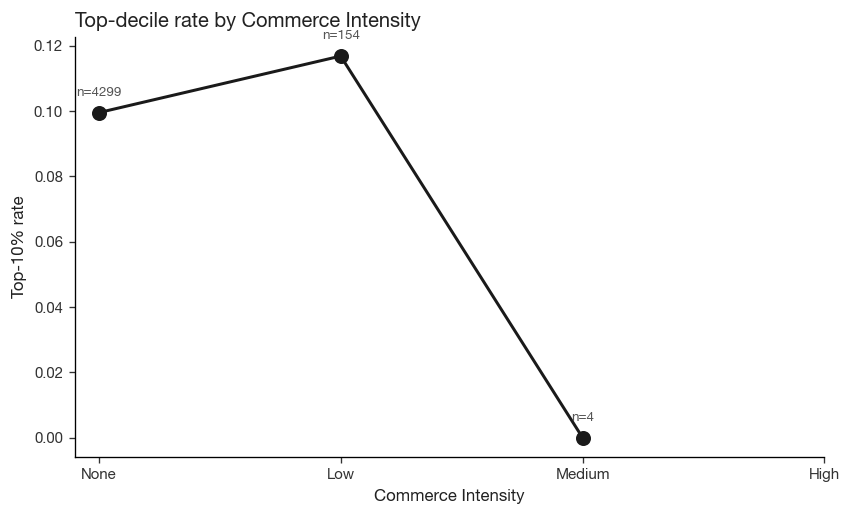

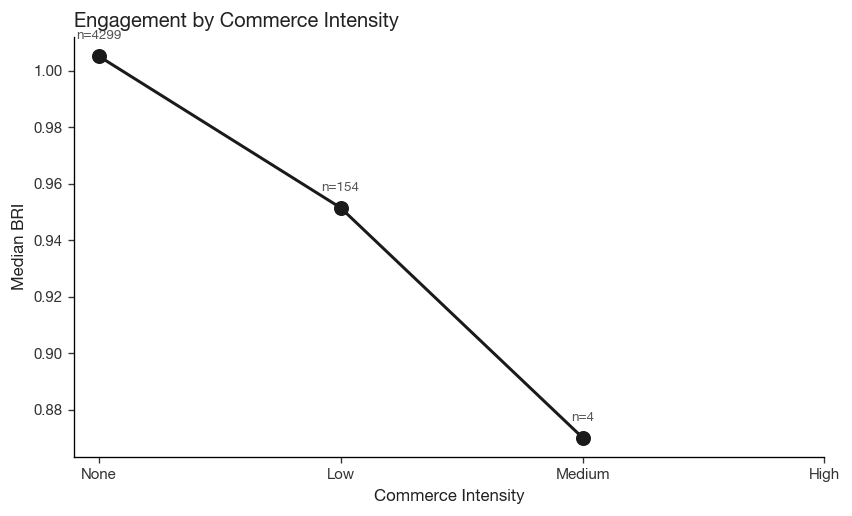

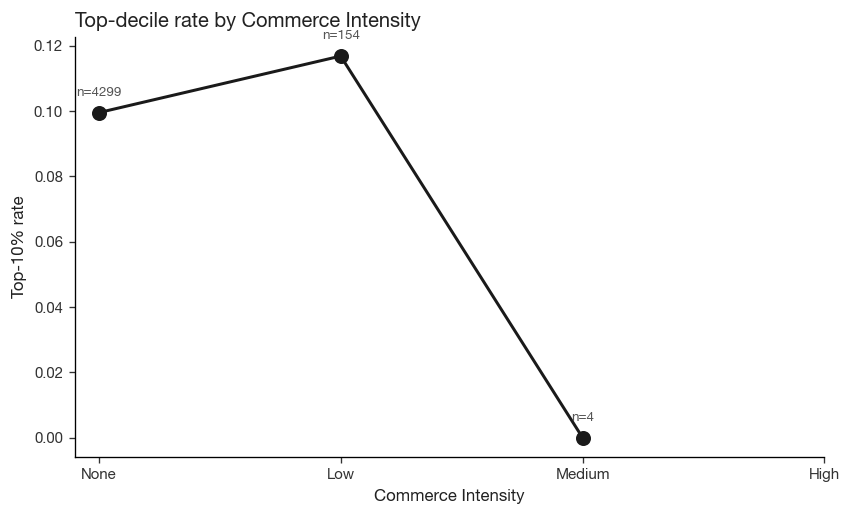

In [6]:
trend = commerce_engagement_trend(df)
thr = trend.attrs.get("wer_threshold")
print(f"Top-10% = WER >= sample Q90 ({thr:.5f})")
display(
    trend.style.format(
        {
            "median_bri": "{:.3f}",
            "median_wer": "{:.4f}",
            "top10_rate": "{:.1%}",
        }
    )
)
display(commerce_engagement_line(trend, y_col="median_bri", ylabel="Median BRI"))
display(
    commerce_engagement_line(
        trend,
        y_col="top10_rate",
        title="Top-decile rate by Commerce Intensity",
        ylabel="Top-10% rate",
    )
)

## 5. Commerce–Engagement matrix

Group bubbles (not single videos):

- X = mean Commerce Intensity
- Y = median BRI
- size = n

Panel A: content presentation. Panel B: product taxonomy.

Dashed lines split at the median of plotted groups (descriptive quadrants, not causal).

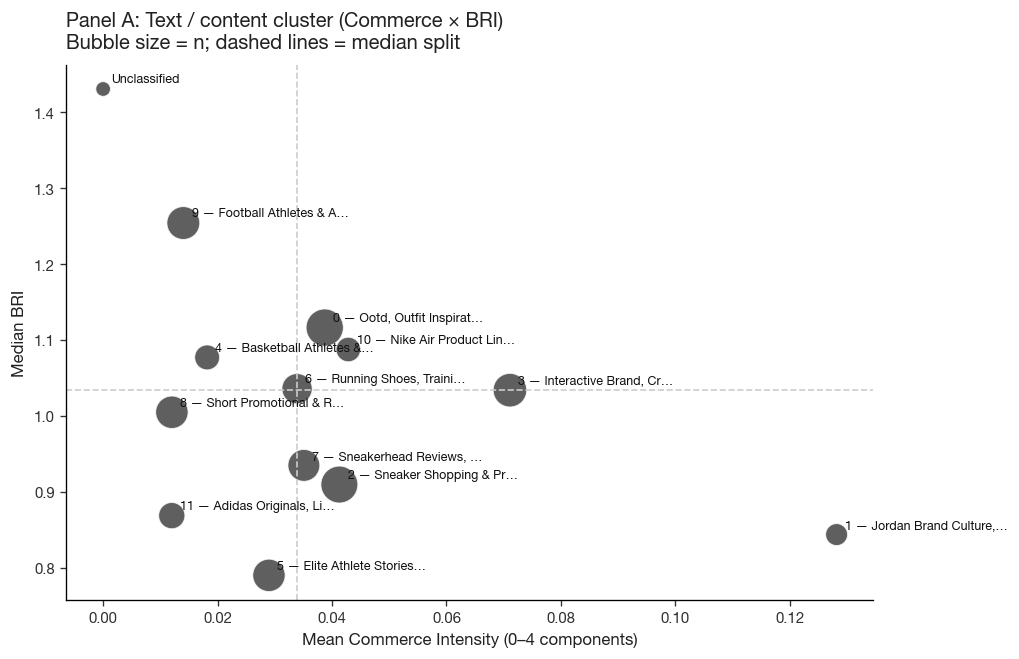

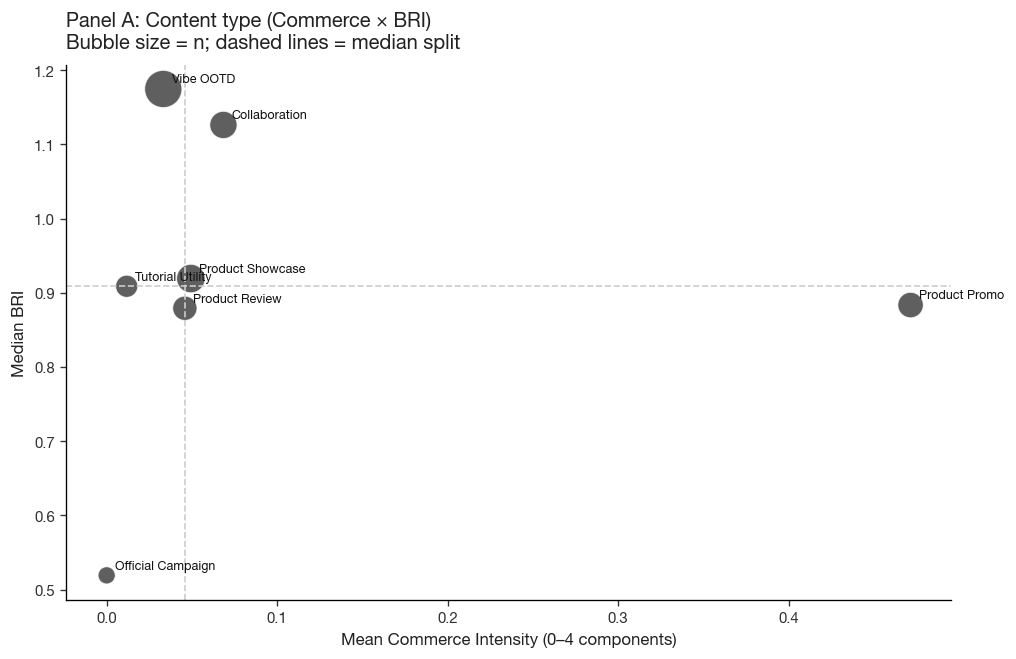

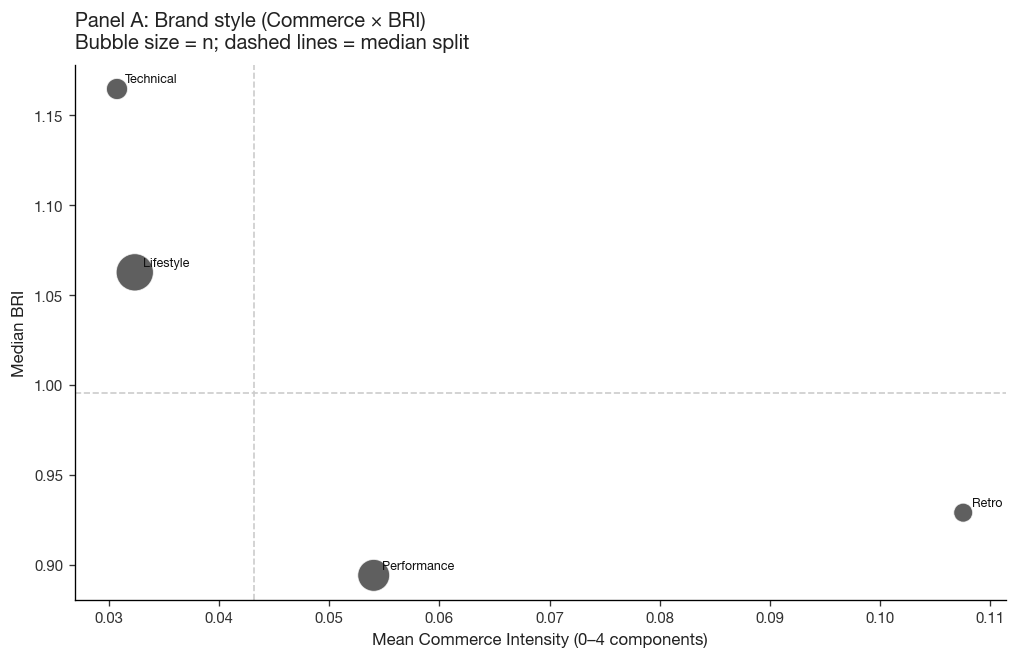

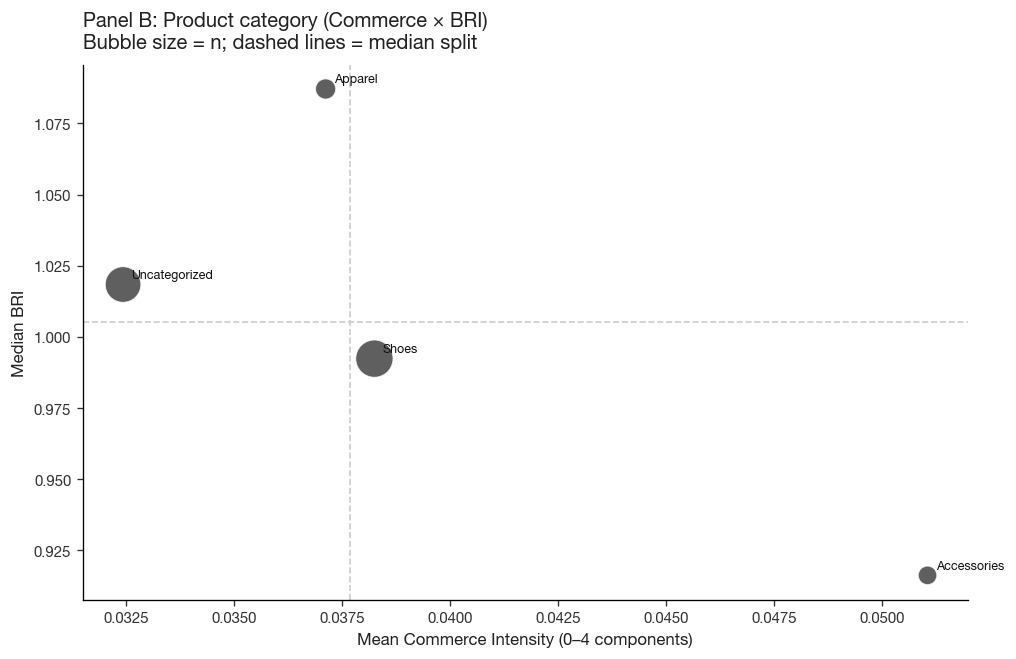

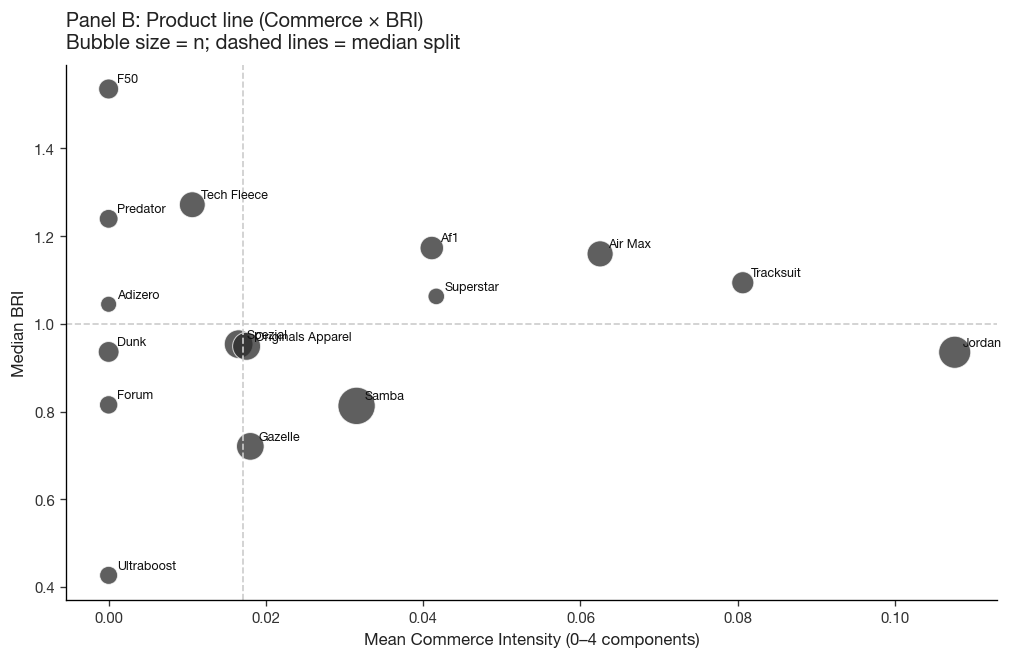

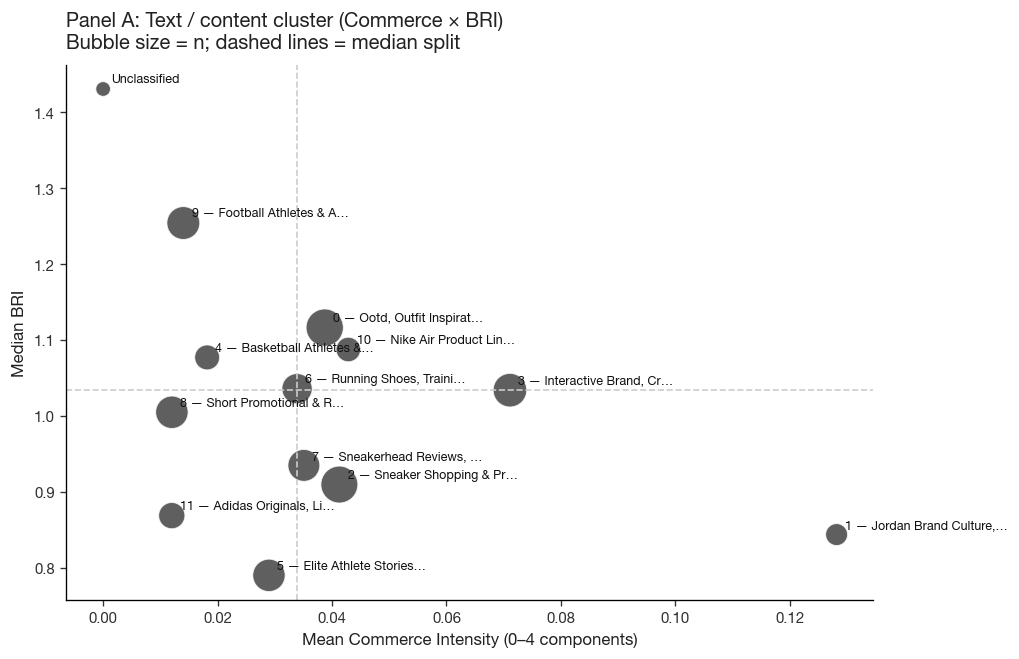

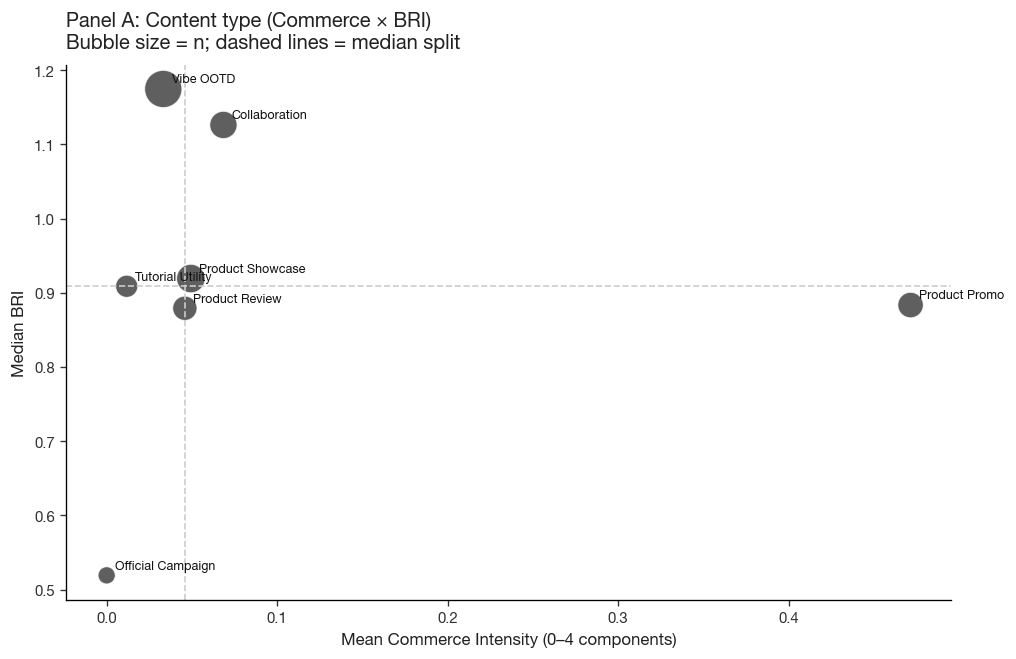

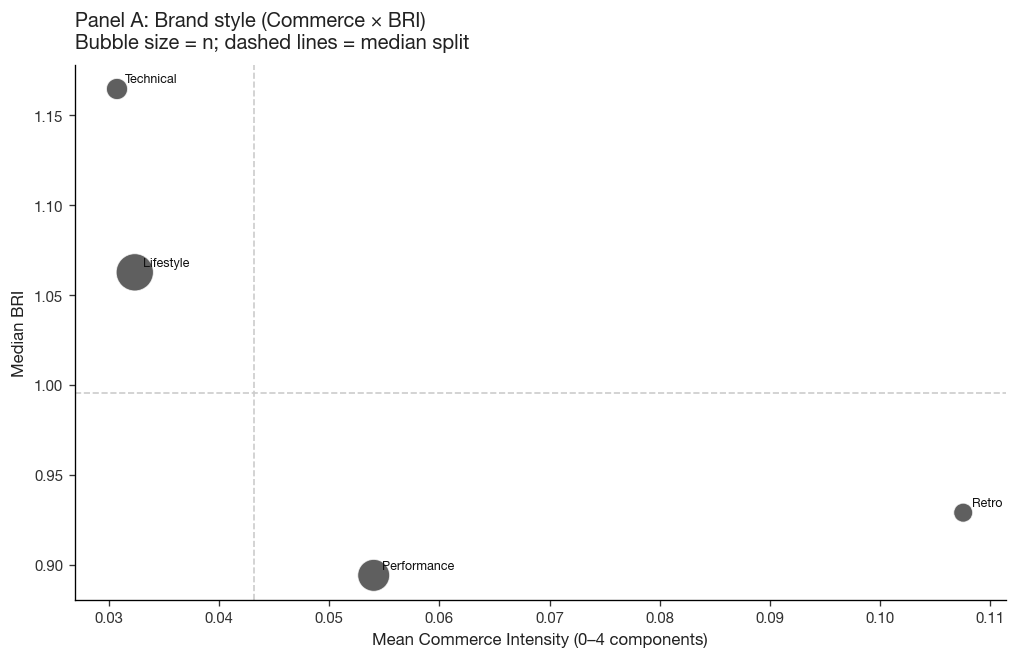

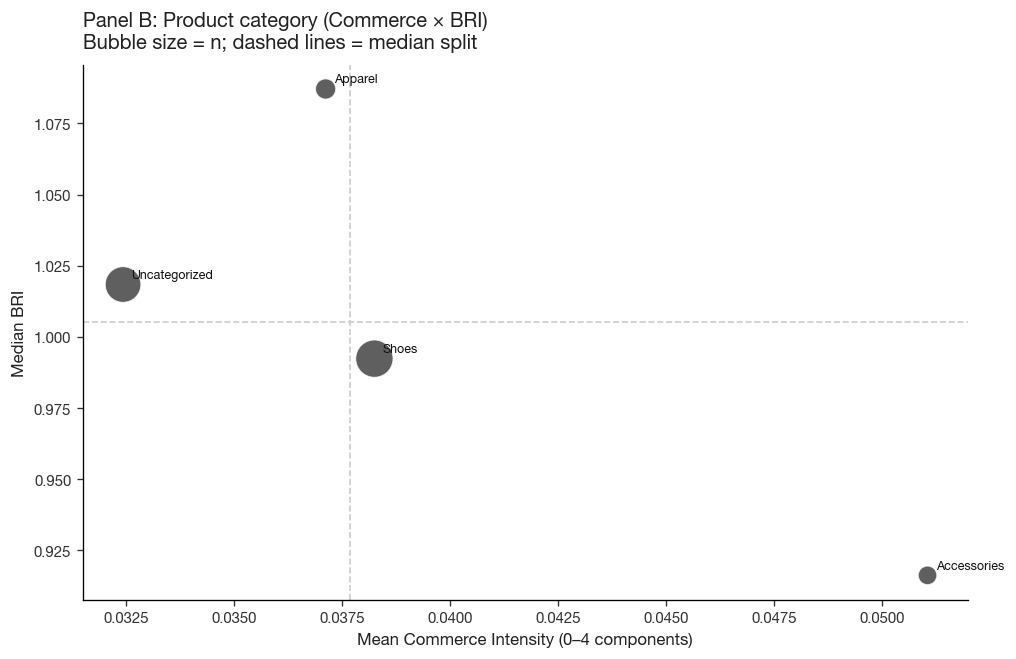

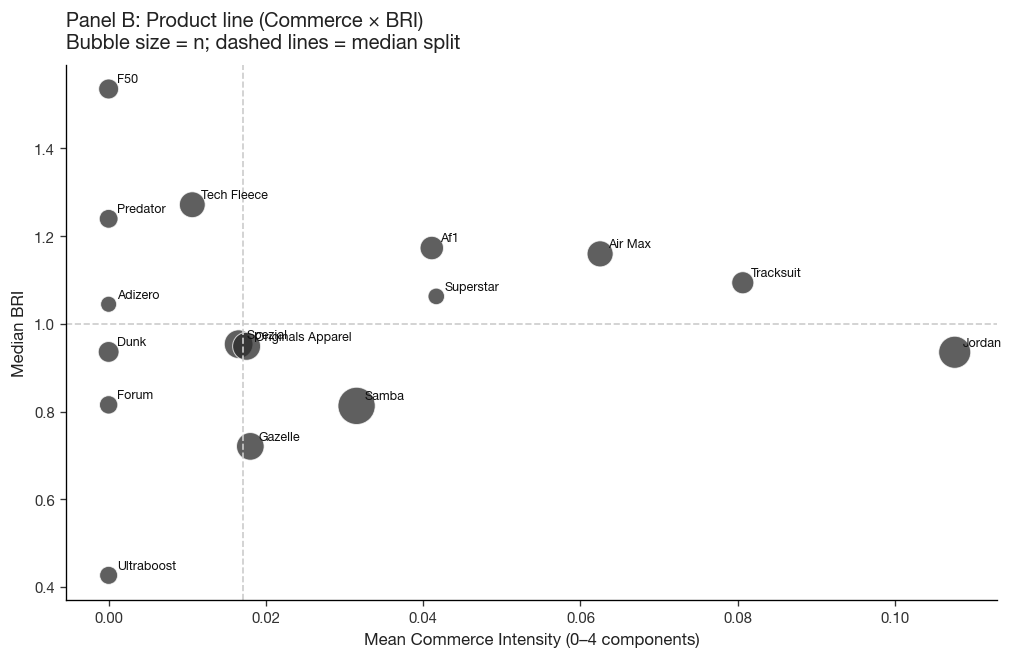

In [7]:
panel_a = ["content_cluster", "content_type", "brand_styles"]
panel_b = ["product_categories", "product_lines"]

for dim in panel_a:
    if dim not in df.columns:
        continue
    bub = commerce_engagement_bubbles(df, dim, min_count=20)
    display(
        commerce_bri_bubbles(
            bub,
            title=f"Panel A: {DIM_LABELS.get(dim, dim)} (Commerce × BRI)",
        )
    )

for dim in panel_b:
    if dim not in df.columns:
        continue
    bub = commerce_engagement_bubbles(df, dim, min_count=15)
    display(
        commerce_bri_bubbles(
            bub,
            title=f"Panel B: {DIM_LABELS.get(dim, dim)} (Commerce × BRI)",
        )
    )

## Takeaways (from this run)

1. **Intensity is sparse.** Mean score ≈ 0.036. Mix: None 4,299 / Low 154 / Medium 4 / High 0. Component rates: purchase 0.8%, discovery 0.9%, promo 1.8%, giveaway 0.1%. Treat Medium/High cells as exploratory only.

2. **Who carries more commerce cues?**
   - Content: `product_promo` stands out (mean 0.47); then collaboration / showcase / review. Official campaign ≈ 0.
   - Cluster: Jordan culture/releases (0.13), interactive/pop-culture (0.07).
   - Style: Retro > Performance > Lifestyle ≈ Technical.
   - Product: accessories slightly above shoes/apparel; lines: Jordan, Tracksuit, Air Max highest.

3. **Nike is more commerce-oriented than Adidas** in this sample (mean 0.050 vs 0.022; Low share 4.7% vs 2.1%). Gap is driven by Nike `product_promo`, Jordan / interactive clusters, and Nike accessories/shoes; Adidas Tracksuit is a local high on Adidas side.

4. **Intensity → engagement:** None median BRI 1.01 → Low 0.95 → Medium 0.87 (n=4). Mild downward lean for Low vs None; not enough High mass to claim a penalty curve. Top-10% rate is slightly higher in Low (11.7%) than None (10.0%).

5. **Matrix (descriptive quadrants):**
   - High-commerce + higher BRI: collaboration; OOTD / interactive clusters; Air Max, AF1, Tracksuit, Superstar.
   - High-commerce + lower BRI: `product_promo`, product review; Jordan cluster; Samba / Gazelle.
   Story: hard promo sits in the weaker-BRI pocket; some product lines and collab/OOTD can sit higher on both axes.
